<a href="https://colab.research.google.com/github/VIctorMartins3519/challenge/blob/master/CP_de_ChatBot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o arquivo CSV
from google.colab import files
uploaded = files.upload()

# Ler o arquivo CSV
df = pd.read_csv('wine_quality_general.csv', encoding='ISO-8859-1')

# Visualizar os primeiros registros
df.head()


Saving wine_quality_general.csv to wine_quality_general.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,tipo,quality,Unnamed: 13
0,7,0.27,0.36,20.7,45.00,45.0,170.0,1001.0000,3.00,0.45,8.8,branco,6,NaN
1,6.3,0.30,0.34,1.6,49.00,14.0,132.0,994.0000,3.30,0.49,9.5,branco,6,NaN
2,8.1,0.28,0.40,6.9,0.05,30.0,97.0,0.9951,3.26,0.44,10.1,branco,6,NaN
3,7.2,0.23,0.32,8.5,58.00,47.0,186.0,0.9956,3.19,0.40,9.9,branco,6,NaN
4,7.2,0.23,0.32,8.5,58.00,47.0,186.0,0.9956,3.19,0.40,9.9,branco,6,NaN


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Remover a coluna desnecessária
df_clean = df.drop(columns=['Unnamed: 13'])

# Verificar dados ausentes
df_clean.isnull().sum()

# Remover possíveis linhas com valores ausentes (caso existam)
df_clean = df_clean.dropna()

# Verificar o tipo de dados
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6361 entries, 0 to 6497
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6361 non-null   object 
 1   volatile acidity      6361 non-null   float64
 2   citric acid           6361 non-null   float64
 3   residual sugar        6361 non-null   float64
 4   chlorides             6361 non-null   float64
 5   free sulfur dioxide   6361 non-null   float64
 6   total sulfur dioxide  6361 non-null   float64
 7   density               6361 non-null   float64
 8   pH                    6361 non-null   float64
 9   sulphates             6361 non-null   float64
 10  alcohol               6361 non-null   float64
 11  tipo                  6361 non-null   object 
 12  quality               6361 non-null   object 
dtypes: float64(10), object(3)
memory usage: 695.7+ KB


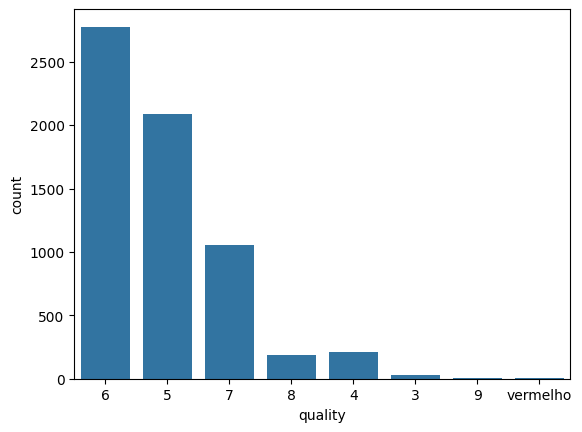

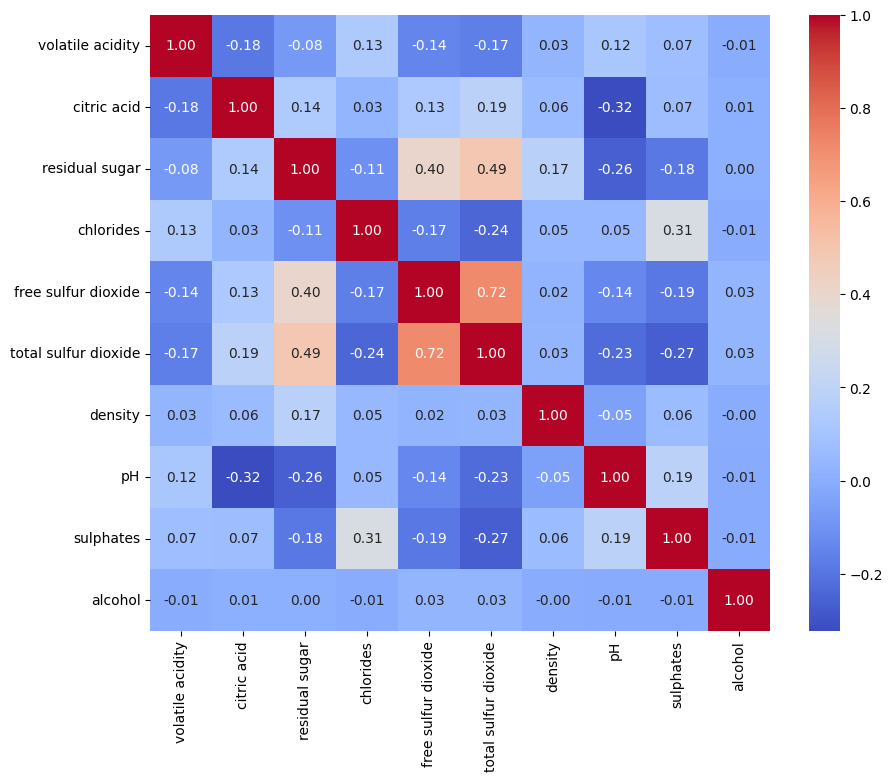

In [ ]:
# Estatísticas descritivas
df_clean.describe()

# Distribuição da variável 'quality'
sns.countplot(x='quality', data=df_clean)
plt.show()

# Matriz de correlação entre as variáveis numéricas
plt.figure(figsize=(10, 8))
# Selecionar apenas colunas numéricas para calcular a correlação
numeric_df = df_clean.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [ ]:
# Dividindo o dataset em variáveis dependentes (X) e independentes (y)
X = df_clean.drop(columns=['quality'])
y = df_clean['quality']

# Dividir entre treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Convert the 'quality' column to numeric before applying pd.cut
y = pd.to_numeric(y, errors='coerce') # errors='coerce' converts non-numeric values to NaN

# Apply pd.cut to the numeric data
y = pd.cut(y, bins=[0, 4, 6, 10], labels=['Ruim', 'Média', 'Boa'])

# Handle any missing values (NaN) if generated by pd.to_numeric
y = y.dropna() # Drop rows with missing values

# Verificando a distribuição de y
print(y.value_counts())

quality
Média    4867
Boa      1251
Ruim      238
Name: count, dtype: int64


In [ ]:
# Codificar novamente a coluna 'tipo'
from sklearn.preprocessing import OneHotEncoder

# Remove the 'sparse' argument
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')  # Usar drop='first' para evitar armadilha da variável dummy, handle_unknown='ignore' para lidar com valores desconhecidos durante o teste
encoded_type = encoder.fit_transform(X[['tipo']])
encoded_type_df = pd.DataFrame(encoded_type.toarray(), columns=encoder.get_feature_names_out(['tipo'])) # Convert to dense array using toarray()

# Remover a coluna original 'tipo' e concatenar as colunas codificadas
X = X.drop(columns=['tipo'])
X = pd.concat([X, encoded_type_df], axis=1)

# ... (rest of your code)

In [ ]:
# Codificar novamente a coluna 'tipo' ANTES de dividir os dados
from sklearn.preprocessing import OneHotEncoder

# Create the encoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')  # Usar drop='first' para evitar armadilha da variável dummy, handle_unknown='ignore' para lidar com valores desconhecidos durante o teste

# Fit the encoder on the 'tipo' column and transform it
encoded_type = encoder.fit_transform(df_clean[['tipo']])
encoded_type_df = pd.DataFrame(encoded_type, columns=encoder.get_feature_names_out(['tipo']))

# Drop the original 'tipo' column and concatenate the encoded columns
df_clean = df_clean.drop(columns=['tipo'])
df_clean = pd.concat([df_clean, encoded_type_df], axis=1)

# Dividindo o dataset em variáveis dependentes (X) e independentes (y) DEPOIS da codificação
X = df_clean.drop(columns=['quality'])
y = df_clean['quality']

# Dividir entre treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ... (rest of your code)